# 딥러닝및실습-2차-김주상-2020136031

# 학습 코드

실행 시 유의사항<br>
- 해당 코드는 .py파일에서 실행한 코드입니다. <br>
- 테스트시 .py파일에 복사하여 테스트 바랍니다.  <br>
- 테스트시 Wandb 로그인 및 설정을 확인해 주시길 바랍니다. <br>
- 테스트시 터미널로 --wandb -b {batch_size} 로 실행하셔야 합니다. <br>

- _01_code/_08_learning_and_optimization/c_my_model_training_with_argparse_wandb.py의 내용을 베이스로 변형하여 만들었습니다.
- 수정한 부분은 다음과 같습니다.
    - SGD -> ADAM
    - Dropout(일부를 랜덤으로 비활성화) : 0.3
    - 학습률 : 0.01 -> 0.001
    - 은닉층 : 20-20 -> 128-64
    - 등등

In [7]:
import torch
from torch import nn, optim
from torch.utils.data import random_split, DataLoader
from datetime import datetime
import wandb
import pandas as pd
import argparse

from pathlib import Path

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

BASE_PATH = str(Path(__file__).resolve().parent.parent.parent) # BASE_PATH: /Users/yhhan/git/link_dl
print("BASE_PATH:", BASE_PATH)

import sys
sys.path.append(BASE_PATH)

from _03_homeworks.homework_2.titanic_dataset \
  import get_preprocessed_dataset, TitanicDataset, TitanicTestDataset


def get_data():
  train_dataset, validation_dataset, test_dataset = get_preprocessed_dataset()

  train_data_loader = DataLoader(dataset=train_dataset, batch_size=wandb.config.batch_size, shuffle=True)
  validation_data_loader = DataLoader(dataset=validation_dataset, batch_size=len(validation_dataset))
  test_data_loader = DataLoader(dataset=test_dataset, batch_size=len(test_dataset))

  return train_data_loader, validation_data_loader, test_data_loader


class MyModel(nn.Module):
  def __init__(self, n_input, n_output):
    super().__init__()

    self.model = nn.Sequential(
      nn.Linear(n_input, wandb.config.n_hidden_unit_list[0]),
      nn.LeakyReLU(),
      nn.Linear(wandb.config.n_hidden_unit_list[0], wandb.config.n_hidden_unit_list[1]),
      nn.LeakyReLU(),
      nn.Dropout(0.3), # 확률적으로 끔
      nn.Linear(wandb.config.n_hidden_unit_list[1], n_output),
    )

  def forward(self, x):
    x = self.model(x)
    return x


def get_model_and_optimizer(input_dim):
  my_model = MyModel(n_input=input_dim, n_output=2)
  # SGD -> ADAM
  optimizer = optim.Adam(my_model.parameters(), lr=wandb.config.learning_rate)

  return my_model, optimizer


def training_loop(model, optimizer, train_data_loader, validation_data_loader):
  n_epochs = wandb.config.epochs
  loss_fn = nn.CrossEntropyLoss()  # Use a built-in loss function
  next_print_epoch = 100

  # 얼리스토핑
  patience = 10  # 10 epoch까지는 참는다
  best_val_loss = float('inf')
  epochs_no_improve = 0

  for epoch in range(1, n_epochs + 1):
    model.train()
    loss_train = 0.0
    num_trains = 0

    for train_batch in train_data_loader:
      input, target = train_batch['input'], train_batch['target']
      output_train = model(input)
      loss = loss_fn(output_train, target)
      loss_train += loss.item()
      num_trains += 1

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

    model.eval()
    loss_validation = 0.0
    num_validations = 0
    correct = 0
    total = 0

    with torch.no_grad():
      for validation_batch in validation_data_loader:
        input, target = validation_batch['input'], validation_batch['target']
        output_validation = model(input)
        loss = loss_fn(output_validation, target)
        loss_validation += loss.item()
        num_validations += 1

        preds = torch.argmax(output_validation, dim=1)
        correct += (preds == target).sum().item()
        total += target.size(0)

    wandb.log({
      "Epoch": epoch,
      "Training loss": loss_train / num_trains,
      "Validation loss": loss_validation / num_validations,
      "Validation accuracy": correct / total
    })

    # 변화 없음 여기서 끝
    if loss_validation / num_validations < best_val_loss:
        best_val_loss = loss_validation / num_validations
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered at epoch {epoch}")
        break

    if epoch >= next_print_epoch:
      print(
        f"Epoch {epoch}, "
        f"Training loss {loss_train / num_trains:.4f}, "
        f"Validation loss {loss_validation / num_validations:.4f}"
        f"Validation accuracy {correct / total:.4f}"
      )
      next_print_epoch += 100


def main(args):
  current_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')

  config = {
    'epochs': args.epochs,
    'batch_size': args.batch_size,
    'learning_rate': 1e-3,
    'n_hidden_unit_list': [128, 64], # 20-20은 아닌거 같음
  }

  wandb.init(
    mode="online" if args.wandb else "disabled",
    project="my_model_training",
    notes="My first wandb experiment",
    tags=["my_model", "california_housing"],
    name=current_time_str,
    config=config
  )
  print(args)
  print(wandb.config)

  train_data_loader, validation_data_loader, test_data_loader = get_data()

  input_dim = next(iter(train_data_loader))['input'].shape[1]
  linear_model, optimizer = get_model_and_optimizer(input_dim)

  print("#" * 50, 1)

  training_loop(
    model=linear_model,
    optimizer=optimizer,
    train_data_loader=train_data_loader,
    validation_data_loader=validation_data_loader
  )

  linear_model.eval()
  all_preds = []

  with torch.no_grad():
      for test_batch in test_data_loader:
          inputs = test_batch['input']
          outputs = linear_model(inputs)
          preds = torch.argmax(outputs, dim=1).numpy()
          all_preds.extend(preds)

  passenger_ids = list(range(892, 1310))

  submission_df = pd.DataFrame({
      "PassengerId": passenger_ids,
      "Survived": all_preds
  })

  submission_df.to_csv("submission.csv", index=False)

  wandb.finish()


# https://docs.wandb.ai/guides/track/config
if __name__ == "__main__":
  parser = argparse.ArgumentParser()

  parser.add_argument(
    "--wandb", action=argparse.BooleanOptionalAction, default=False, help="True or False"
  )

  parser.add_argument(
    "-b", "--batch_size", type=int, default=512, help="Batch size (int, default: 512)"
  )

  parser.add_argument(
    "-e", "--epochs", type=int, default=1_000, help="Number of training epochs (int, default:1_000)"
  )

  args = parser.parse_args()

  main(args)


NameError: name '__file__' is not defined

 * 실행 결과
C:\Users\USER\anaconda3\envs\link_dl\python.exe C:\Users\USER\git\link_dl\_04_your_code\hw2_1.py --wandb -b 128
C:\Users\USER\anaconda3\envs\link_dl\lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
C:\Users\USER\anaconda3\envs\link_dl\lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
BASE_PATH: C:\Users\USER\git
wandb: Currently logged in as: jusang3057 (jusang3057-korea-university-of-technology-and-education) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.22.2
wandb: Run data is saved locally in C:\Users\USER\git\link_dl\_04_your_code\wandb\run-20251018_192552-4m8pd30k
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run 2025-10-18_19-25-51
wandb:  View project at https://wandb.ai/jusang3057-korea-university-of-technology-and-education/my_model_training
wandb:  View run at https://wandb.ai/jusang3057-korea-university-of-technology-and-education/my_model_training/runs/4m8pd30k
Namespace(wandb=True, batch_size=128, epochs=1000)
{'epochs': 1000, 'batch_size': 128, 'learning_rate': 0.001, 'n_hidden_unit_list': [128, 64]}
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'title', 'family_num', 'alone'],
      dtype='object')
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  title  family_num  alone
0       0.0       3    1  22.0      1      0   7.2500         2      2           1    0.0
1       1.0       1    0  38.0      1      0  71.2833         0      3           1    0.0
2       1.0       3    0  26.0      0      0   7.9250         2      1           0    1.0
3       1.0       1    0  35.0      1      0  53.1000         2      3           1    0.0
4       0.0       3    1  35.0      0      0   8.0500         2      2           0    1.0
5       0.0       3    1  29.0      0      0   8.4583         1      2           0    1.0
6       0.0       1    1  54.0      0      0  51.8625         2      2           0    1.0
7       0.0       3    1   2.0      3      1  21.0750         2      0           4    0.0
8       1.0       3    0  27.0      0      2  11.1333         2      3           2    0.0
9       1.0       2    0  14.0      1      0  30.0708         0      3           1    0.0
?? 891 891
Data Size: 891, Input Shape: torch.Size([891, 10]), Target Shape: torch.Size([891])
################################################## 1
Early stopping triggered at epoch 69
wandb: updating run metadata
wandb:
wandb: Run history:
wandb:               Epoch ▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇████
wandb:       Training loss █▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: Validation accuracy ▄▁▄▅▄▅▅▄▅▅▅▅▅▅▅▅▅▅▅▅▆▆▇▆▇█▆▆██▇███▇█████
wandb:     Validation loss █▅▇▅▆▆▅▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▄▃▄▂▃▂▃▂▂▁▂▄▂▁▁▂▁▁
wandb:
wandb: Run summary:
wandb:               Epoch 69
wandb:       Training loss 0.46097
wandb: Validation accuracy 0.81461
wandb:     Validation loss 0.47764
wandb:
wandb:  View run 2025-10-18_19-25-51 at: https://wandb.ai/jusang3057-korea-university-of-technology-and-education/my_model_training/runs/4m8pd30k
wandb:  View project at: https://wandb.ai/jusang3057-korea-university-of-technology-and-education/my_model_training
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: .\wandb\run-20251018_192552-4m8pd30k\logs

종료 코드 0(으)로 완료된 프로세스


# 결과

wandb : https://wandb.ai/jusang3057-korea-university-of-technology-and-education/my_model_training/runs/qf0zi30v?nw=nwuserjusang3057

- 배치 사이즈 테스트
    - 조건
        - ReLU사용
        - learning_rate : 0.001
        - n_hidden_unit_list : [128, 64]
        - Dropout : 0.3

    - Validation accuracy(3회 테스트하여 평균 구함)
        - 16 : 0.73596, 0.80899, 0.81461	0.7865
        - 32 : 0.82022, 0.75281, 0.78652	0.7865
        - 64 : 0.79775, 0.81461, 0.74719	0.7865
        - 128 : 0.82584, 0.80899, 0.82584	0.8202



- 배치 사이즈 테스트
    - 조건
        - batch_size : 128
        - learning_rate : 0.001
        - n_hidden_unit_list : [128, 64]
        - Dropout : 0.3

    - Validation accuracy(3회 테스트하여 평균 구함)
        - ReLU : 0.79213, 0.83146, 0.77528		0.7996
        - Sigmoid : 0.7809, 0.87079, 0.73596	0.7959
        - ELU : 0.8427, 0.80899, 0.76404		0.8052
        - LeakyReLU : 0.81461, 0.82022, 0.7809	0.8052

LeakyReLU <br>
batch_size : 128 <br>
learning_rate : 0.001 <br>
n_hidden_unit_list : [128, 64] <br>
Dropout : 0.3 <br>

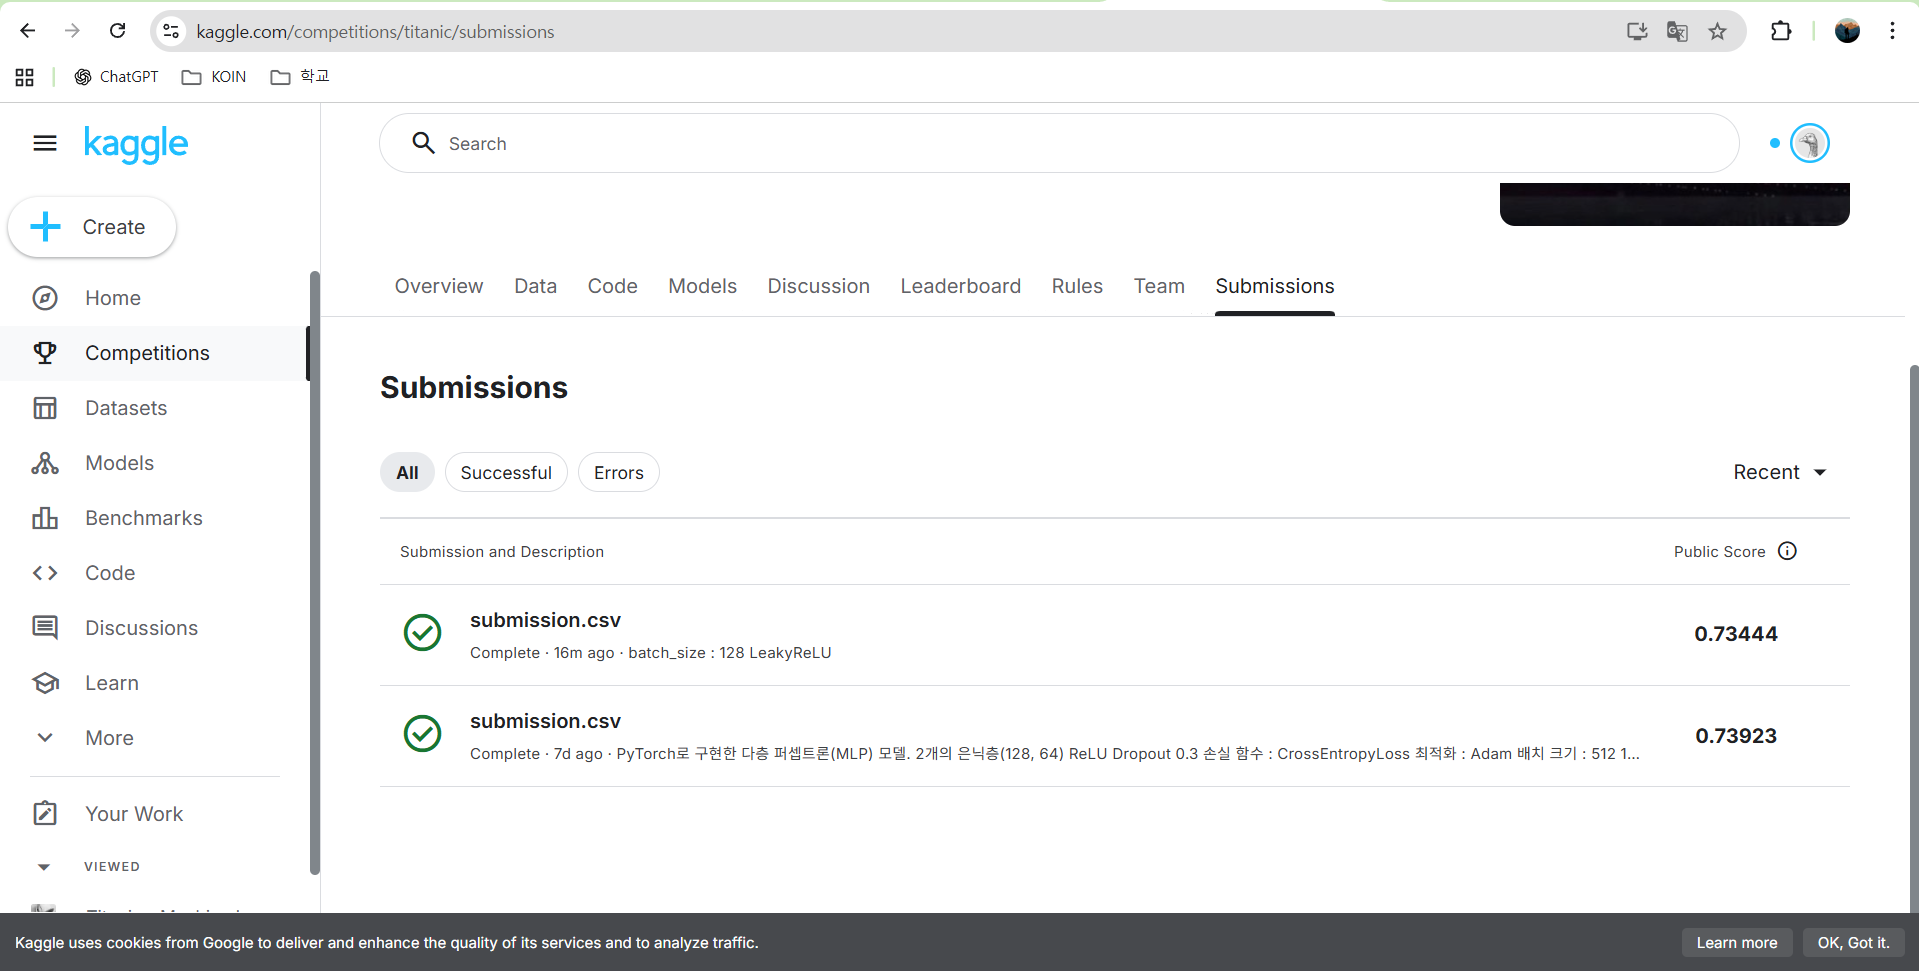

# 숙제 후기

이번 숙제를 통해 딥러닝 모델을 실제 데이터에 적용해보며, 모델 설계와 학습 과정에서 고려해야 할 여러 요소를 직접 경험할 수 있었다. Titanic 데이터를 기반으로 다층 퍼셉트론을 구현하고, 입력 데이터 전처리부터 학습, 검증, 그리고 최종 예측까지 전체 파이프라인을 구성해보았다. 특히 배치 사이즈, 학습률, 은닉층 크기등의 하이퍼파라미터가 모델 성능에 미치는 영향을 직접 실험하고 비교하면서 많은 것을 배울 수 잇었다.

또한, 활성화 함수(ReLU, Sigmoid, ELU, LeakyReLU)에 따라 학습 곡선과 검증 성능이 달라지는 것을 관찰하며, 각 함수의 특징과 학습 안정성에 대한 이해를 깊게 할 수 있었다. ReLU 계열이 전체적으로 안정적인 학습을 보이는 반면, Sigmoid는 일부 조건에서 학습 속도가 느리거나 불안정해지는 것을 확인했고, ELU와 LeakyReLU는 과적합과 일반화 성능 사이에서 균형을 잡는 장점을 보여주었다.

얼리 스토핑(Early Stopping)을 적용함으로써, 검증 손실이 일정 횟수 이상 개선되지 않으면 학습을 중단하도록 설정했고, 이를 통해 불필요한 학습으로 인한 과적합을 방지할 수 있었다. 또한 wandb를 활용해 학습 과정과 검증 성능을 실시간으로 모니터링하고, 실험 설정과 결과를 체계적으로 기록함으로써 학습 과정에서 얻은 인사이트를 시각적으로 확인할 수 있었다. 

다만 확률(30%)적으로 은닉층의 일부를 비활성화 해서인지, 얼리 스토핑의 에폭스 개수나, 정확도가 많이 들쭉날쭉하여 얼리 스토핑 및 활성화 함수, 배치 사이즈에 대한 결과값이 정확한 값인지는 잘 모르겠다는 것이 아쉬웠다. 그래도, 이번 숙제를 통해 단순히 코드를 구현하는 것을 넘어, 데이터 전처리, 모델 설계, 하이퍼파라미터 튜닝, 학습 모니터링, 결과 분석까지 포함한 딥러닝 실험의 전체 과정을 경험하며, 실질적인 실습 역량을 크게 향상시킬 수 있었다.